# Practice Lab : Linear Regression

In this lab i would be implementing a linear regression with one variabele to predict profits for a restaurant franchise.

_**Note**: this is a practice project ment to polish the fundamentals of aiml_

## 1 - Packages

run the cell below to import all the packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy 
import math 

## 2 - Problem Statement

Use the data provided to find the cities which may potentially give a restaurant business higher profits

## 3 - Dataset

In [3]:
data = "../../datasets/ex1data1.txt"
df = pd.read_csv(data)
x_train = df["population"]
y_train = df["profit"]

In [4]:
# print x_train
print("Type of x_train:",type(x_train))
print("The shape of x_train is:",x_train.shape)
print("First five elements of x_train are:\n" , x_train.head()) 



Type of x_train: <class 'pandas.Series'>
The shape of x_train is: (97,)
First five elements of x_train are:
 0    6.1101
1    5.5277
2    8.5186
3    7.0032
4    5.8598
Name: population, dtype: float64


In [5]:
# print y_train
print("Type of y_train:",type(y_train))
print("The shape of y_train is:",y_train.shape)
print("First five elements of y_train are:\n", y_train.head())  

Type of y_train: <class 'pandas.Series'>
The shape of y_train is: (97,)
First five elements of y_train are:
 0    17.5920
1     9.1302
2    13.6620
3    11.8540
4     6.8233
Name: profit, dtype: float64


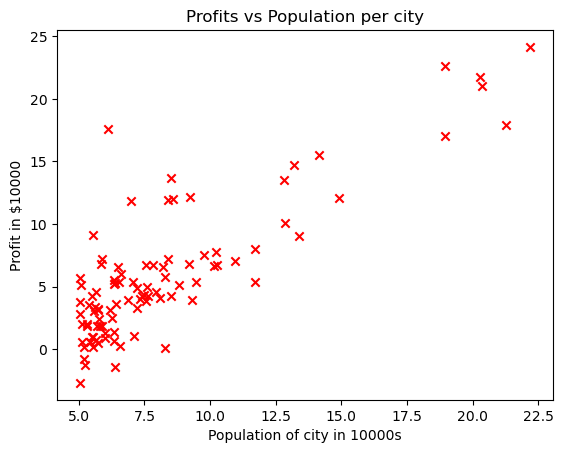

In [7]:
plt.scatter(x_train,y_train,marker="x",c="r")

plt.title("Profits vs Population per city")
plt.ylabel("Profit in $10000")
plt.xlabel("Population of city in 10000s")
plt.show()

## Linear Regression Model 

### Linear regression with one variable

The model function for lnear regression which maps x to y can be represented as

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

### Cost Function of the Linear Regression Model

The cost function for linear regression $J(w,b)$ is defined as:

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

### Compute Cost Function

In [12]:
def comp_cost(x,y,w,b):
    '''
    Computes the cost function for linear regression

    Args:
        x (array) : the feature part of the database
        y (array) : the label part of the database
        w,b : parameters of the model

    Returns:
        total_cost of using w,b as parameters for linear regression
    '''

    m = x.shape[0] #number of training exaples
    total_cost = 0 #retrun variable
    cost_sum = 0  

    for i in range(m):
        f_wb = x[i]*w + b
        cost_wb = (f_wb - y[i])**2

        cost_sum += cost_wb

    total_cost = (1/(2*m)) * cost_sum

    return total_cost

In [ ]:
# Compute cost with some initial values for paramaters w, b # downloaded testcase
initial_w = 2
initial_b = 1

cost = comp_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')


<class 'numpy.float64'>
Cost at initial w: 75.203


### Gradient Descent

The Gradient Descent algorithm is 

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & \phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; & 
\newline & \rbrace\end{align*}$$

where, parameters $w, b$ are both updated simultaniously and where  
$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$

In [ ]:
def comp_gradient(x,y,w,b):
    '''
    Compute the gradient for linear regression

    Args:
        x (array) : the feature part of the database
        y (array) : the label part of the database
        w,b : parameters of the model

    returns:
        dj_db : the gradient of the cost wrt to b
        dj_dw : the gradient of the cost wrt to w
    '''

    m = x.shape[0]

    dj_db = 0
    dj_dw = 0

    for i in range(m):
        f_wbi = x[i]*w + b # Model function for that instance
        dj_dbi = (f_wb - y[i])
        dj_dwi = (f_wb - y[i])*x[i]

